In [1]:
import pandas as pd
from ax.service.ax_client import AxClient, ObjectiveProperties
import matplotlib.pyplot as plt
from ax.modelbridge.factory import Models
from ax.modelbridge.generation_strategy import GenerationStep, GenerationStrategy      
import helper_functions as hf

SyntaxError: invalid syntax (helper_functions.py, line 43)

In [2]:
ax_client_init_file_name = 'optimizer/optimizer_init.json'
ax_client = hf.optimizer_init()
ax_client

[INFO 04-29 10:49:09] ax.service.ax_client: Starting optimization with verbose logging. To disable logging, set the `verbose_logging` argument to `False`. Note that float values in the logs are rounded to 6 decimal points.
[INFO 04-29 10:49:09] ax.service.utils.instantiation: Created search space: SearchSpace(parameters=[RangeParameter(name='r1', parameter_type=INT, range=[0, 27]), RangeParameter(name='r2', parameter_type=INT, range=[0, 27]), RangeParameter(name='r3', parameter_type=INT, range=[0, 27]), RangeParameter(name='r4', parameter_type=INT, range=[0, 27]), RangeParameter(name='r5', parameter_type=INT, range=[0, 27]), RangeParameter(name='r6', parameter_type=INT, range=[0, 27]), RangeParameter(name='r7', parameter_type=INT, range=[0, 27]), RangeParameter(name='r8', parameter_type=INT, range=[0, 27]), RangeParameter(name='r9', parameter_type=INT, range=[0, 27]), RangeParameter(name='r10', parameter_type=INT, range=[0, 27]), RangeParameter(name='r11', parameter_type=INT, range=[0,

AxClient(experiment=Experiment(None))

In [3]:
ax_client.save_to_json_file(ax_client_init_file_name)


[INFO 04-29 10:49:10] ax.service.ax_client: Saved JSON-serialized state of optimization to `optimizer/optimizer_init.json`.


In [4]:
optimizer_file_path = 'optimizer/optimizer_'


for i in range(5):

    batch_size = 1
    parameterizations, optimization_complete = ax_client.get_next_trials(batch_size)
    for trial_index, parameterization in list(parameterizations.items()):
        # extract parameters

        r1 = parameterization["r1"]
        r2 = parameterization["r2"]
        r3 = parameterization["r3"]
        r4 = parameterization["r4"]
        r5 = parameterization["r5"]
        r6 = parameterization["r6"]
        r7 = parameterization["r7"]
        r8 = parameterization["r8"]
        r9 = parameterization["r9"]
        r10 = parameterization["r10"]
        r11 = parameterization["r11"]
        r12 = parameterization["r12"]

        results = hf.virtual_exp(r1, r2, r3, r4, r5, r6, r7, r8, r9, r10, r11, r12)
        ax_client.complete_trial(trial_index=trial_index, raw_data=results)

        ax_client.save_to_json_file(optimizer_file_path + str(i) + '.json')
        print("Trial {} completed.".format(trial_index))
        



[INFO 04-29 10:49:11] ax.service.ax_client: Encountered exception indicating optimization completion: Rejection sampling error (specified maximum draws (10000) exhausted, without finding sufficiently many (1) candidates). This likely means that there are no new points left in the search space.
[INFO 04-29 10:49:11] ax.service.ax_client: Encountered exception indicating optimization completion: Rejection sampling error (specified maximum draws (10000) exhausted, without finding sufficiently many (1) candidates). This likely means that there are no new points left in the search space.
[INFO 04-29 10:49:11] ax.service.ax_client: Encountered exception indicating optimization completion: Rejection sampling error (specified maximum draws (10000) exhausted, without finding sufficiently many (1) candidates). This likely means that there are no new points left in the search space.
[INFO 04-29 10:49:11] ax.service.ax_client: Encountered exception indicating optimization completion: Rejection sam

In [10]:
objectives = ax_client.objective_names
df = ax_client.get_trials_data_frame()
pareto_results = ax_client.get_pareto_optimal_parameters()

[INFO 04-29 09:33:22] ax.modelbridge.transforms.standardize_y: Outcome complexity is constant, within tolerance.
/Users/zeqing/opt/anaconda3/envs/sdlnano_plot/lib/python3.11/site-packages/botorch/models/utils/assorted.py:267: InputDataWarning: Data (outcome observations) is not standardized (std = tensor([0.0000, 1.0000, 1.0000], dtype=torch.float64), mean = tensor([ 0.0000e+00, -3.3307e-17,  4.4409e-17], dtype=torch.float64)).Please consider scaling the input to zero mean and unit variance.
  check_standardization(Y=train_Y, raise_on_fail=raise_on_fail)


In [11]:
df

,trial_index,arm_name,trial_status,generation_method,generation_node,complexity,cost,performance,r1,r2,r3,r4,r5,r6,r7,r8,r9,r10,r11,r12
0,0,0_0,COMPLETED,Sobol,GenerationStep_0,12.0,6.732985,1.244802,0.475107,0.592524,0.494479,0.313852,0.956092,0.083302,0.098763,0.347466,0.846915,0.761508,0.882807,0.880169
1,1,1_0,COMPLETED,Sobol,GenerationStep_0,12.0,5.684614,0.462721,0.861477,0.166011,0.504516,0.570255,0.086635,0.600777,0.807654,0.809979,0.369148,0.372135,0.183181,0.352846
2,2,2_0,COMPLETED,Sobol,GenerationStep_0,12.0,4.383001,0.459535,0.530153,0.888269,0.161508,0.108681,0.271814,0.796786,0.367982,0.515712,0.060535,0.000032,0.453061,0.228468
3,3,3_0,COMPLETED,Sobol,GenerationStep_0,12.0,6.141397,0.200648,0.135028,0.369958,0.839498,0.853366,0.654210,0.278900,0.538070,0.076857,0.535900,0.616034,0.737804,0.505771
4,4,4_0,COMPLETED,Sobol,GenerationStep_0,12.0,6.233772,0.141257,0.004971,0.848399,0.744539,0.991378,0.576699,0.184836,0.469659,0.718018,0.222328,0.476403,0.298922,0.697620


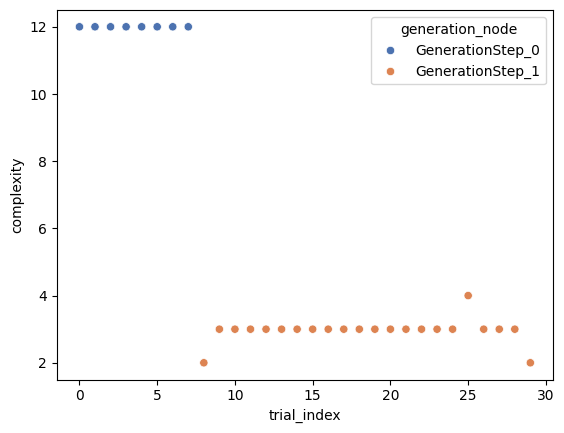

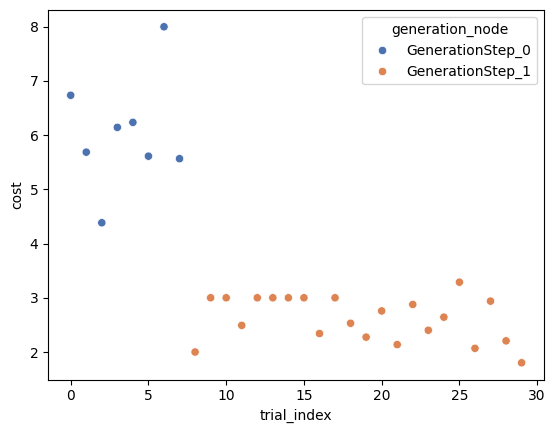

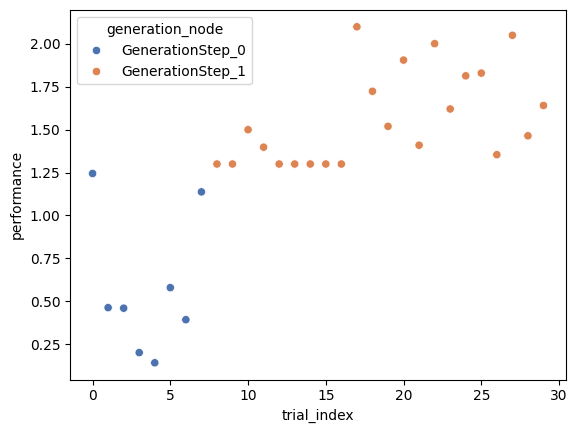

In [28]:
import seaborn as sns

for col in objectives:
    fig = plt.figure()
    sns.scatterplot(data=df, x='trial_index', y=col, hue='generation_node', palette='deep')